In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split

y = pd.read_csv("/work/y_combined_scaled_new.csv", index_col=0)
X = pd.read_csv("/work/X_combined_scaled_new.csv", index_col=0)


In [4]:
len(y)


2766

In [7]:
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import numpy as np
import statsmodels.api as sm

def rolling_har_predict_daily_np(X, y, train_days=441, retrain_every=63):
    """
    Predicts one day at a time using a HAR model trained every `retrain_every` days.

    Parameters:
    - X: 2D numpy array of features, shape (n_samples, n_features)
    - y: 1D numpy array of target, shape (n_samples,)
    - train_days: number of days used to train the model (default: 441)
    - retrain_every: number of days between model retraining (default: 63)

    Returns:
    - predictions: 1D numpy array of predictions
    - pred_indices: 1D numpy array of indices corresponding to prediction positions
    """
    n_samples = X.shape[0]
    predictions = []
    pred_indices = []

    model = None

    for i in range(train_days, n_samples):
        # Retrain model every `retrain_every` days or if no model yet
        if (i - train_days) % retrain_every == 0 or model is None:
            train_X = X[i - train_days:i, :]
            train_y = y[i - train_days:i]
            train_X_const = sm.add_constant(train_X, has_constant='add')
            model = sm.OLS(train_y, train_X_const).fit()

        test_X = sm.add_constant(X[i:i+1, :], has_constant='add')

        # Check for NaNs in test_X
        if np.isnan(test_X).any():
            print(f"Skipping prediction at index {i} due to NaNs in test_X")
            continue

        pred = model.predict(test_X)[0]
        predictions.append(pred)
        pred_indices.append(i)

    predictions = np.array(predictions)
    pred_indices = np.array(pred_indices)
    print(f"Generated {len(predictions)} predictions (expected: {n_samples - train_days})")
    return predictions, pred_indices


In [13]:
import numpy as np

def rolling_frame_har(X, y, train_days=441, predict_days=63):
    """
    Rolling HAR framework using NumPy arrays.

    Parameters:
    - X: np.ndarray, shape (n_samples, n_features)
    - y: np.ndarray, shape (n_samples,)
    - train_days: int, number of days to use for training
    - predict_days: int, number of days to predict each round

    Returns:
    - predictions: np.ndarray, shape (n_total_preds,)
      Contains all predictions concatenated in chronological order
    - prediction_indices: np.ndarray
      The indices corresponding to the predictions
    """

    n = len(y)
    predictions = []
    prediction_indices = []

    start = 0
    while start + train_days + predict_days <= n:
        X_train = X[start:start+train_days]
        y_train = y[start:start+train_days]
        X_test = X[start+train_days:start+train_days+predict_days]

        # Handle NaNs if needed — up to you how strict
        if np.isnan(X_train).any() or np.isnan(y_train).any() or np.isnan(X_test).any():
            print(f"Skipping window at index {start} due to NaNs.")
            start += predict_days
            continue

        # === Fill this in with your model ===
        # model = YourModel()
        # model.fit(X_train, y_train)

        X_train_with_constant = sm.add_constant(X_train)
        har_model = sm.OLS(y_train, X_train_with_constant).fit()


        # y_pred = model.predict(X_test)
        X_test = sm.add_constant(X_test)

# Predict using your HAR model
        y_pred = har_model.predict(X_test)
        
        # ================================

        predictions.append(y_pred)
        prediction_indices.append(np.arange(start+train_days, start+train_days+predict_days))

        start += predict_days

    return np.concatenate(predictions), np.concatenate(prediction_indices)


In [16]:
pred_ser = rolling_frame_har(np.array(X), np.array(y), train_days=441, predict_days=63)

In [19]:
len(X)


2766

In [22]:
pred_ser

(array([ 0.14514641,  0.30446398,  0.33667171, ..., -0.11225878,
        -0.28798525, -0.32909354]),
 array([ 441,  442,  443, ..., 2706, 2707, 2708]))

In [9]:
X

,VIX,STR,MKT,Jump,DPR,DS,RV_day,RV_week,RV_month,SPX Index - Volume
Date,,,,,,,,,,
2019-10-29,-0.681163,0.570886,-0.113458,-0.171472,-0.918520,0.063812,-0.347920,-0.674107,-0.281050,-0.781624
2019-10-30,-0.801766,0.601273,0.249440,-0.174704,-0.918570,-0.107385,-0.704213,-0.692059,-0.324625,-0.638960
2019-10-31,-0.678391,0.277149,-0.307683,-0.173411,-0.918507,-0.107385,-0.623109,-0.664125,-0.329657,0.125326
2019-11-01,-0.805925,-0.320455,0.818995,-0.090751,-0.918681,-0.150185,-0.384163,-0.626688,-0.359528,-0.540633
2019-11-04,-0.732454,-1.080120,0.289788,-0.070147,-0.918750,-0.107385,-0.341608,-0.548500,-0.410851,-0.481108
...,...,...,...,...,...,...,...,...,...,...
2025-04-24,1.158379,2.515629,1.750530,-0.182461,-0.923568,-0.620979,3.055561,1.475267,2.781316,0.941306
2025-04-25,0.932422,0.499984,0.606098,-0.166220,-0.923669,-0.663778,-0.099093,1.200834,2.740612,0.601516
2025-04-28,0.975395,0.621530,0.008208,-0.182461,-0.923678,-0.620979,0.132056,1.129070,2.785636,0.375515


In [25]:
predictions, prediction_indices = rolling_frame_har(np.array(X), np.array(y), train_days=441, predict_days=63)

In [10]:
predictions = pred_ser.values

AttributeError: 'tuple' object has no attribute 'values'

In [109]:
len(predictions)

Data starts at: 2019-10-29
Data ends at: 2025-04-30
Length of X: 1383


In [67]:
import joblib
import numpy as np
# Load scaler later
scaler = joblib.load('y_scaler_combined_new.pkl')
from sklearn.metrics import mean_absolute_percentage_error

import numpy as np
import statsmodels.api as sm

# # Define the scoring function
# def score(y_hat, y, metric="MSE"):
#     if metric == "MSE":
#         return np.mean((y_hat - y) ** 2)
#     else:
#         raise NotImplementedError(f"Metric '{metric}' not implemented.")

# # Add constant to X_train for statsmodels if needed
# X_test = sm.add_constant(X_test)

# # Predict using your HAR model
# y_pred_z = har_model2.predict(X_test)  # shape: (n_samples,)

# # Inverse transform to get predictions in original scale
# y_hat_is = scaler.inverse_transform(np.array(y_pred_z).reshape(-1, 1))  # shape: (n_samples, 1)

# # Inverse transform y_train as well
# y_true_is = scaler.inverse_transform(np.array(y_test.values).reshape(-1, 1))  # shape: (n_samples, 1)

# # Compute MSE
# mse_is = score(y_hat_is, y_true_is, metric="MSE")

mape = mean_absolute_percentage_error(scaler.inverse_transform(np.array(y[442:].values.ravel()).reshape(-1, 1)), scaler.inverse_transform(np.array(predictions).reshape(-1, 1)))




print(f"Mean Absolute Percentage Error (MAPE): {mape:.6f}")
print(f"MAPE as percentage: {mape * 100:.2f}%")

/root/venv/lib/python3.10/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.1.3. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  try:


ValueError: Found input variables with inconsistent numbers of samples: [941, 882]

In [1]:
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error

# Load your scaler
scaler = joblib.load('y_scaler_combined_new.pkl')

# Assume this is your HAR prediction function call
# Make sure you've already run this:
# predictions, prediction_indices = rolling_frame_har(X, y)

# Get true y values that correspond to predictions
y_true = y[prediction_indices]

# Inverse transform both y_true and predictions to get values in original scale
y_true_inverse = scaler.inverse_transform(np.array(y_true).reshape(-1, 1))
y_pred_inverse = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Compute MAPE
mape = mean_absolute_percentage_error(y_true_inverse, y_pred_inverse)

# Print the result
print(f"Mean Absolute Percentage Error (MAPE): {mape:.6f}")
print(f"MAPE as percentage: {mape * 100:.2f}%")


NameError: name 'y' is not defined

In [28]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error

# Load your scaler
scaler = joblib.load('y_scaler_combined_new.pkl')


y_true = y.iloc[prediction_indices]  

# Reshape and inverse transform
y_true = scaler.inverse_transform(np.array(y_true).reshape(-1, 1))
y_pred = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"MAPE: {mape:.6f} ({mape * 100:.2f}%)")

MAPE: 0.245799 (24.58%)


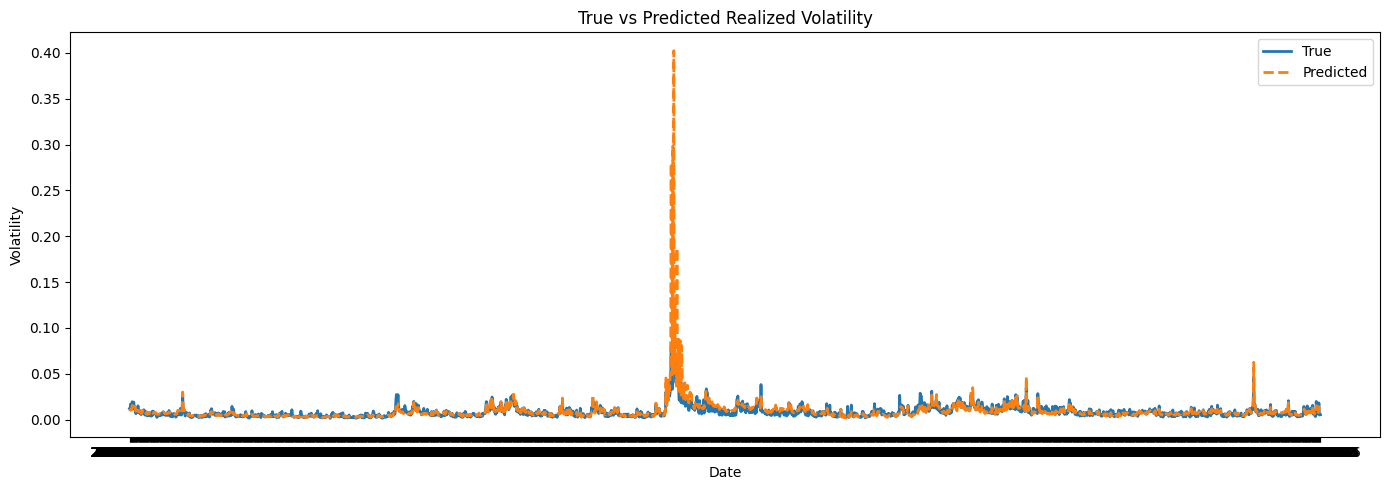

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Get the prediction dates
prediction_dates = y.index[prediction_indices]

# Step 2: Build a DataFrame for easy plotting
df_plot = pd.DataFrame({
    'Date': prediction_dates,
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
}).set_index('Date')

# Step 3: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()


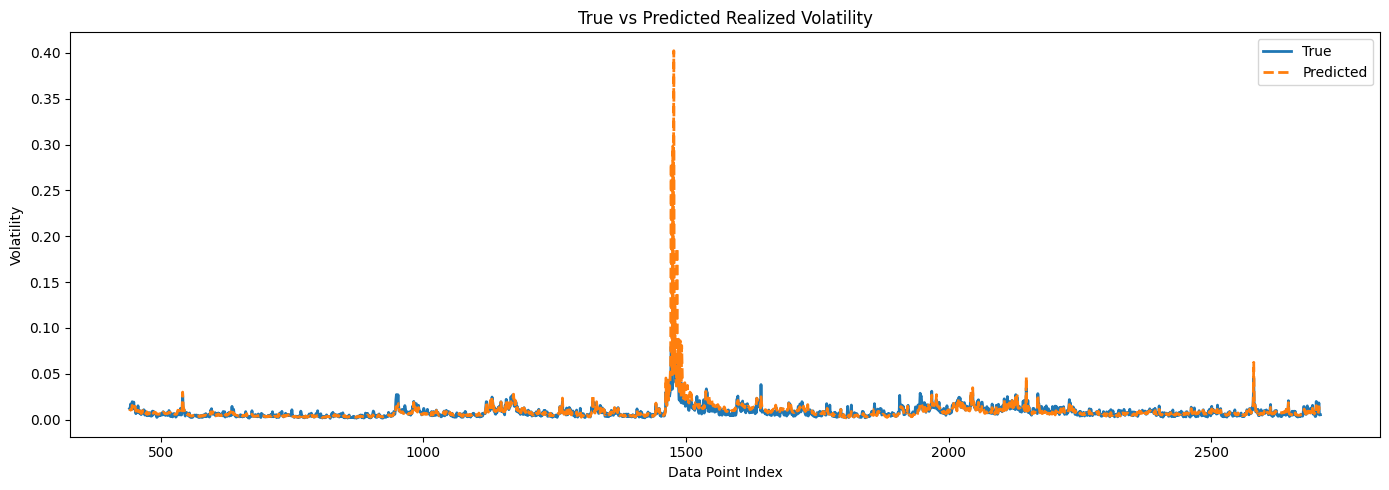

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Build a DataFrame using just index numbers
df_plot = pd.DataFrame({
    'Index': prediction_indices,
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
}).set_index('Index')

# Step 2: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Data Point Index')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()
